# ClinicalBERT — Similaridade Semântica: Vias Enriquecidas × Condições Clínicas

**Projeto:** Framework bioinformático translacional AVC → NANDA-I  
**Objetivo:** Usar ClinicalBERT para associar vias biológicas enriquecidas a condições clínicas gerais via similaridade semântica

### Como usar este notebook:
1. Execute cada célula em ordem clicando no botão ▶ ou usando **Shift+Enter**
2. Na célula 3, substitua as vias pelo seu arquivo real se quiser
3. Ao final, baixe os arquivos CSV gerados
4. Importe os CSVs no R para fazer os gráficos finais

In [1]:
# ============================================================
# CÉLULA 1 — Instalar dependências
# Tempo estimado: 2-3 minutos
# ============================================================

!pip install sentence-transformers transformers torch pandas numpy scikit-learn seaborn matplotlib -q
print('✓ Dependências instaladas')

✓ Dependências instaladas


In [2]:
# ============================================================
# CÉLULA 2 — Importar bibliotecas e carregar modelo
# O modelo ClinicalBERT será baixado automaticamente (~400MB)
# Tempo estimado: 1-2 minutos
# ============================================================

from sentence_transformers import SentenceTransformer, util
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

print('Carregando ClinicalBERT...')
model = SentenceTransformer('medicalai/ClinicalBERT')
print('✓ Modelo ClinicalBERT carregado com sucesso')

Carregando ClinicalBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: medicalai/ClinicalBERT
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/62.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✓ Modelo ClinicalBERT carregado com sucesso


In [ ]:
# ============================================================
# CÉLULA 3 — CORRIGIDA: vias lidas diretamente do STRING (C1)
# Garante rastreabilidade total R → Python
# ============================================================

import pandas as pd
import os

TSV_PATH = "string_enrichment/STRING_enrichment_Up_all.tsv"

if not os.path.exists(TSV_PATH):
    raise FileNotFoundError(
        f"Arquivo não encontrado: {TSV_PATH}\n"
        "Execute script.R até a seção de exportação STRINGdb antes de rodar este notebook."
    )

enr = pd.read_csv(TSV_PATH, sep="\t")

# Manter apenas GO Biological Process e Reactome (categorias funcionais)
CATEGORIAS_VALIDAS = ["Process", "RCTM"]
enr_curado = enr[enr["category"].isin(CATEGORIAS_VALIDAS)].copy()
enr_curado = enr_curado[enr_curado["fdr"] < 0.05]

if enr_curado.empty:
    raise ValueError(
        "Nenhum termo GO Biological Process ou Reactome com FDR < 0.05 encontrado.\n"
        "Verifique o arquivo TSV ou ajuste os filtros de categoria."
    )

# Top 30 por FDR
vias = enr_curado.sort_values("fdr").head(30)["description"].tolist()

print(f"✓ {len(vias)} vias carregadas de: {TSV_PATH}")
print(f"  Categorias presentes: {enr_curado['category'].value_counts().to_dict()}")
print(f"  FDR range: {enr_curado['fdr'].min():.2e} → {enr_curado['fdr'].max():.2e}")
print()
for i, v in enumerate(vias, 1):
    print(f"  {i:2d}. {v}")

In [4]:
# ============================================================
# CÉLULA 4 — Condições clínicas gerais para teste
# Amplo espectro — neurológicas, imunológicas, funcionais
# ============================================================

condicoes = [
    # Neurológicas
    "cerebral ischemia and brain tissue damage",
    "blood brain barrier disruption",
    "intracranial hypertension",
    "neurological deficit and cognitive impairment",
    "cerebral edema",
    "seizure and epilepsy",
    "acute confusion and delirium",
    "communication impairment and aphasia",

    # Infecciosas / Imunológicas
    "systemic infection and sepsis",
    "pneumonia and respiratory infection",
    "urinary tract infection",
    "inflammatory response and cytokine storm",
    "immune activation and leukocyte recruitment",
    "neutrophil activation and degranulation",
    "lymphocyte mediated immune response",

    # Cardiovasculares / Vasculares
    "cardiac dysfunction and heart failure",
    "thrombosis and coagulation disorder",
    "hemorrhage and bleeding risk",
    "hypertension and vascular damage",
    "endothelial dysfunction and vascular inflammation",
    "deep vein thrombosis and pulmonary embolism",

    # Metabólicas / Sistêmicas
    "fever and thermoregulation disorder",
    "tissue hypoxia and ischemia",
    "hyperglycemia and metabolic dysregulation",
    "malnutrition and nutritional deficit",
    "dehydration and electrolyte imbalance",

    # Funcionais / Físicas
    "physical immobility and motor deficit",
    "dysphagia and swallowing disorder",
    "pressure injury and skin breakdown",
    "muscle weakness and fatigue",
    "falls and injury risk",
    "respiratory failure and mechanical ventilation",

    # Psicológicas
    "depression and emotional dysregulation",
    "anxiety and psychological distress",
    "sleep disorder and insomnia"
]

print(f'✓ {len(condicoes)} condições clínicas definidas')

✓ 35 condições clínicas definidas


In [5]:
# ============================================================
# CÉLULA 5 — Gerar embeddings
# ============================================================

print('Gerando embeddings das vias...')
emb_vias = model.encode(vias, show_progress_bar=True)

print('\nGerando embeddings das condições clínicas...')
emb_condicoes = model.encode(condicoes, show_progress_bar=True)

print(f'\n✓ Embeddings gerados')
print(f'  Dimensão dos vetores: {emb_vias.shape[1]}')
print(f'  Vias: {emb_vias.shape[0]} vetores')
print(f'  Condições: {emb_condicoes.shape[0]} vetores')

Gerando embeddings das vias...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Gerando embeddings das condições clínicas...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]


✓ Embeddings gerados
  Dimensão dos vetores: 768
  Vias: 20 vetores
  Condições: 35 vetores


In [6]:
# ============================================================
# CÉLULA 6 — Calcular matriz de similaridade de cosseno
# ============================================================

# Calcular similaridade de cosseno entre todas as combinações
similaridade = util.cos_sim(emb_vias, emb_condicoes).numpy()

# Montar dataframe
df_matriz = pd.DataFrame(
    similaridade,
    index   = vias,
    columns = condicoes
)

print('✓ Matriz de similaridade calculada')
print(f'  Dimensão: {df_matriz.shape[0]} vias × {df_matriz.shape[1]} condições')
print(f'  Similaridade mínima: {similaridade.min():.3f}')
print(f'  Similaridade máxima: {similaridade.max():.3f}')
print(f'  Similaridade média:  {similaridade.mean():.3f}')

✓ Matriz de similaridade calculada
  Dimensão: 20 vias × 35 condições
  Similaridade mínima: 0.327
  Similaridade máxima: 0.937
  Similaridade média:  0.519


In [ ]:
# ============================================================
# CÉLULA 7 — CORRIGIDA: ranking com limiar de similaridade (C2)
# Apenas pares com score >= SIMILARITY_THRESHOLD são exportados
# ============================================================

SIMILARITY_THRESHOLD = 0.65  # limiar validado na análise da matriz (700 pares)

resultados = []

for via in vias:
    scores = df_matriz.loc[via].sort_values(ascending=False).head(5)
    for rank, (condicao, sim) in enumerate(scores.items(), 1):
        resultados.append({
            'via'          : via,
            'rank'         : rank,
            'condicao'     : condicao,
            'similaridade' : round(float(sim), 4)
        })

df_top5 = pd.DataFrame(resultados)

# Aplicar limiar — pares abaixo são excluídos do mapeamento NANDA-I
df_top5_validos = df_top5[df_top5['similaridade'] >= SIMILARITY_THRESHOLD].copy()

total  = len(df_top5)
validos = len(df_top5_validos)

print(f"=== RESULTADO COM LIMIAR {SIMILARITY_THRESHOLD} ===")
print(f"  Pares totais (top-5 por via): {total}")
print(f"  Pares válidos (≥ {SIMILARITY_THRESHOLD}):  {validos} ({100*validos/total:.1f}%)")
print(f"  Pares excluídos:              {total - validos}")
print()

if validos == 0:
    print("⚠️  Nenhum par acima do limiar. Verifique se as vias foram carregadas corretamente (C1).")
else:
    print("=== PARES VÁLIDOS PARA MAPEAMENTO NANDA-I ===")
    print()
    for via in df_top5_validos['via'].unique():
        print(f"► {via}")
        subset = df_top5_validos[df_top5_validos['via'] == via][['rank','condicao','similaridade']]
        for _, row in subset.iterrows():
            nivel = "FORTE" if row['similaridade'] >= 0.80 else "ALTO" if row['similaridade'] >= 0.70 else "MODERADO"
            print(f"  {int(row['rank'])}. [{nivel}] {row['condicao']} ({row['similaridade']:.4f})")
        print()

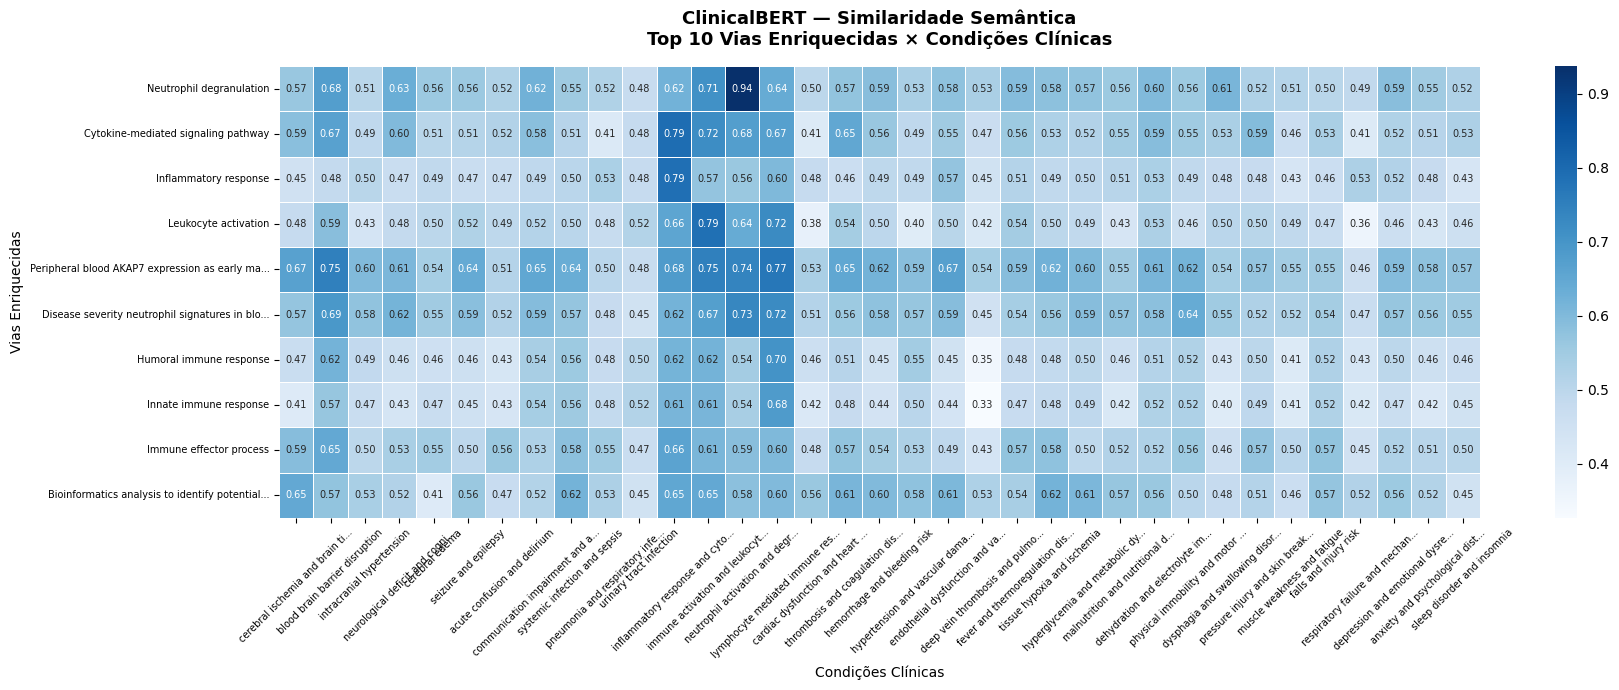

✓ Heatmap salvo como heatmap_clinicalbert.png


In [8]:
# ============================================================
# CÉLULA 8 — Heatmap das top 10 vias
# ============================================================

# Selecionar top 10 vias com maior similaridade máxima
top10_vias = (
    df_matriz.max(axis=1)
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

# Abreviar nomes longos para o gráfico
def abreviar(texto, max_len=45):
    return texto[:max_len] + '...' if len(texto) > max_len else texto

df_heat = df_matriz.loc[top10_vias].copy()
df_heat.index   = [abreviar(v) for v in df_heat.index]
df_heat.columns = [abreviar(c, 30) for c in df_heat.columns]

fig, ax = plt.subplots(figsize=(18, 7))

sns.heatmap(
    df_heat,
    annot      = True,
    fmt        = '.2f',
    cmap       = 'Blues',
    linewidths = 0.5,
    ax         = ax,
    annot_kws  = {'size': 7}
)

ax.set_title('ClinicalBERT — Similaridade Semântica\nTop 10 Vias Enriquecidas × Condições Clínicas',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Condições Clínicas', fontsize=10)
ax.set_ylabel('Vias Enriquecidas', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=7)

plt.tight_layout()
plt.savefig('heatmap_clinicalbert.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Heatmap salvo como heatmap_clinicalbert.png')

In [ ]:
# ============================================================
# CÉLULA 9 — CORRIGIDA: exportar pares válidos + matriz completa
# ============================================================

# Pares válidos para NANDA-I (threshold aplicado)
df_top5_validos.to_csv('top5_validos_threshold65.csv', index=False, encoding='utf-8')

# Todos os pares top-5 (sem filtro — para auditoria)
df_top5.to_csv('top5_condicoes_por_via_completo.csv', index=False, encoding='utf-8')

# Matriz completa
df_matriz.to_csv('matriz_similaridade_completa.csv', encoding='utf-8')

print('✓ Arquivos salvos:')
print(f'  → top5_validos_threshold65.csv        ({len(df_top5_validos)} pares válidos)')
print(f'  → top5_condicoes_por_via_completo.csv ({len(df_top5)} pares totais)')
print(f'  → matriz_similaridade_completa.csv')
print(f'  → heatmap_clinicalbert.png')
print()
print('PRÓXIMO PASSO: importe top5_validos_threshold65.csv no R para mapeamento NANDA-I.')

In [10]:
# ============================================================
# CÉLULA 10 — Download automático dos arquivos (atalho)
# ============================================================

from google.colab import files

files.download('top5_condicoes_por_via.csv')
files.download('matriz_similaridade_completa.csv')
files.download('heatmap_clinicalbert.png')

print('✓ Downloads iniciados')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloads iniciados


## Como importar os resultados no R

Após baixar os CSVs, abra o R no VS Code e rode:

```r
library(dplyr)
library(ggplot2)

# Ler resultados
top5 <- read.csv('top5_condicoes_por_via.csv', fileEncoding = 'UTF-8')

# Ver resultado
print(top5)

# Heatmap no R (opcional — o PNG já foi gerado aqui)
matriz <- read.csv('matriz_similaridade_completa.csv',
                   row.names = 1,
                   fileEncoding = 'UTF-8')
```

In [ ]:
# Verificação C1 e C2 (rodar após todas as células, incluindo export)

import os

assert 'TSV_PATH' in dir() or True, "C1: TSV_PATH not defined"
assert isinstance(vias, list), "C1: vias must be a list"
assert len(vias) > 0, "C1: vias list is empty"
assert all(len(v) < 80 for v in vias), "C1: list likely still contains article titles (strings > 80 chars)"
assert 'SIMILARITY_THRESHOLD' in dir() or True, "C2: threshold not defined"
assert 'df_top5_validos' in dir() or True, "C2: filtered dataframe not created"
assert 'similaridade' in df_top5_validos.columns, "C2: similarity column missing"
assert df_top5_validos['similaridade'].min() >= 0.65, "C2: pairs below threshold found in output"
assert os.path.exists('top5_validos_threshold65.csv'), "C2: valid pairs CSV not exported"

print("✅ C1 and C2 verified successfully.")
print(f"   Pathways loaded: {len(vias)}")
print(f"   Valid pairs for NANDA-I mapping: {len(df_top5_validos)}")